In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Amazon_Reviews.xlsx to Amazon_Reviews.xlsx


In [3]:
!pip install openpyxl wordcloud

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

In [5]:
df = pd.read_excel("Amazon_Reviews.xlsx")

In [7]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (21214, 9)


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up andâ€¦,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       21213 non-null  object
 1   Profile Link        21163 non-null  object
 2   Country             21054 non-null  object
 3   Review Count        21055 non-null  object
 4   Review Date         21055 non-null  object
 5   Rating              21055 non-null  object
 6   Review Title        21054 non-null  object
 7   Review Text         21055 non-null  object
 8   Date of Experience  20947 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB


In [9]:
print(df.isnull().sum())

Reviewer Name           1
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          160
Review Text           159
Date of Experience    267
dtype: int64


In [10]:
df = df.dropna(subset=["Review Text"])

print("Updated Shape:", df.shape)

Updated Shape: (21055, 9)


In [11]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [12]:
df["Rating_Number"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r"(\d)")
    .astype(int)
)

In [13]:
df[["Rating","Rating_Number"]].head()

,Rating,Rating_Number
0,Rated 1 out of 5 stars,1
1,Rated 1 out of 5 stars,1
2,Rated 1 out of 5 stars,1
3,Rated 1 out of 5 stars,1
4,Rated 1 out of 5 stars,1


In [14]:
def classify_sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"

In [15]:
df["Sentiment"] = df["Rating_Number"].apply(classify_sentiment)

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,Rating_Number,Sentiment
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024",1,Negative
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up andâ€¦,Had multiple orders one turned up and driver h...,"September 16, 2024",1,Negative
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024",1,Negative
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024",1,Negative
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024",1,Negative


In [16]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Negative    14350
Positive     5820
Neutral       885
Name: count, dtype: int64


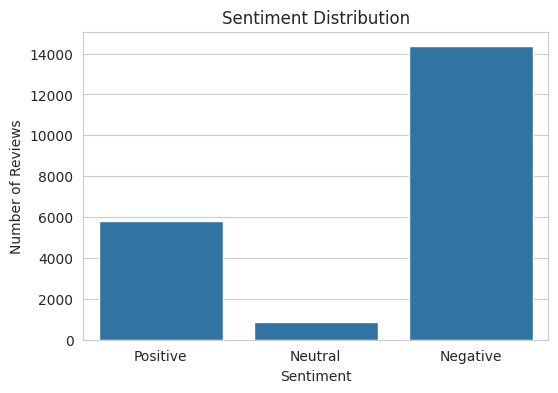

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Sentiment",
    order=["Positive","Neutral","Negative"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

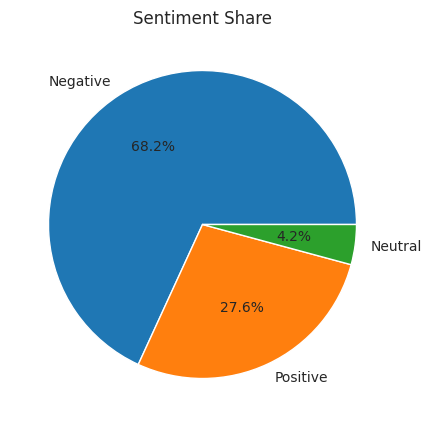

In [18]:
plt.figure(figsize=(5,5))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Sentiment Share")

plt.show()

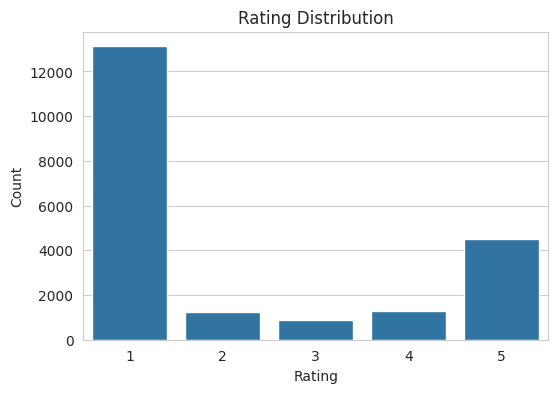

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Rating_Number"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

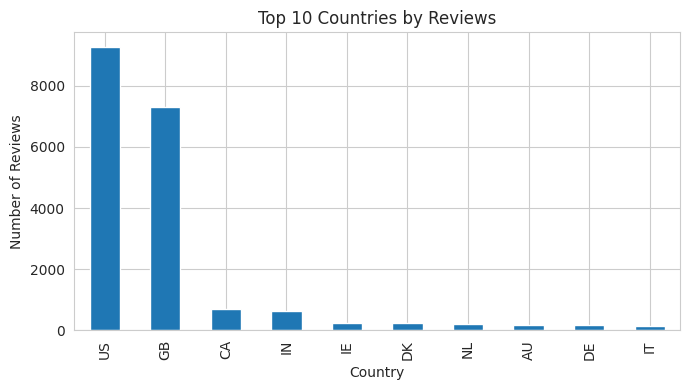

In [20]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(7,4))

top_countries.plot(
    kind="bar"
)

plt.title("Top 10 Countries by Reviews")
plt.xlabel("Country")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

In [21]:
df["Review_Length"] = (
    df["Review Text"]
    .astype(str)
    .apply(len)
)

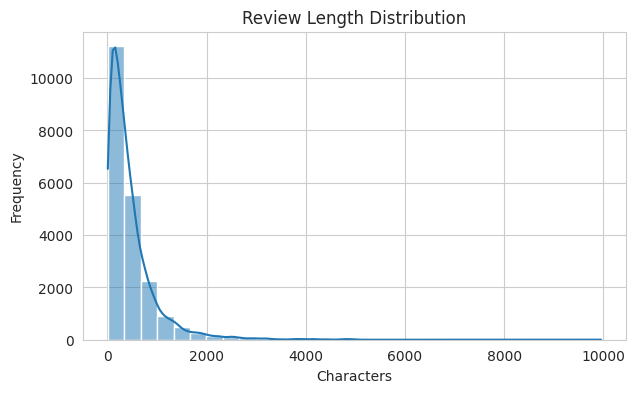

In [22]:
plt.figure(figsize=(7,4))

sns.histplot(
    df["Review_Length"],
    bins=30,
    kde=True
)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

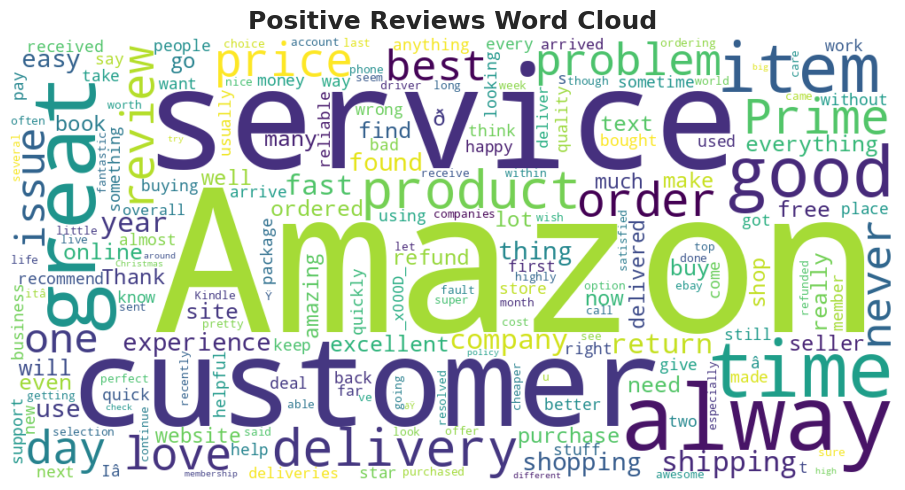

In [31]:
# Extract Positive Reviews
positive_reviews = df[df["Sentiment"] == "Positive"]

# Combine All Positive Review Text
positive_text = " ".join(
    positive_reviews["Review Text"].astype(str)
)


positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(positive_text)


plt.figure(figsize=(10, 5))

plt.imshow(
    positive_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Positive Reviews Word Cloud",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

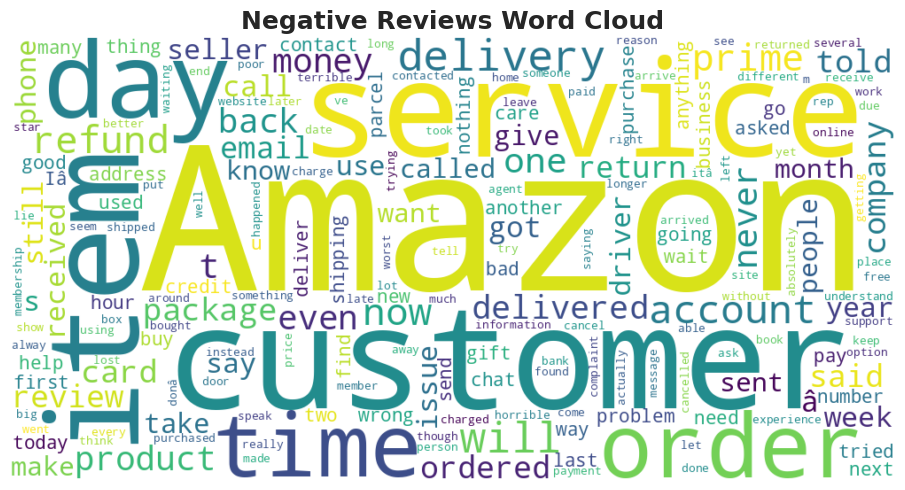

In [32]:
# Extract Negative Reviews
negative_reviews = df[df["Sentiment"] == "Negative"]

# Combine All Negative Review Text
negative_text = " ".join(
    negative_reviews["Review Text"].astype(str)
)


negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(negative_text)


plt.figure(figsize=(10, 5))

plt.imshow(
    negative_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Negative Reviews Word Cloud",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [36]:
df.to_excel(
    "Sentiment_Analysis_Result.xlsx",
    index=False
)

print("Results Saved Successfully!")

Results Saved Successfully!


In [37]:
from google.colab import files

files.download(
    "Sentiment_Analysis_Result.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>